# 02 — Exploratory Data Analysis
### European Used Car Prices (2023–2025) · Unified Dataset

**Sections:**
1. Dataset overview & basic stats
2. Missing value analysis (overall + by year heatmap)
3. Price distributions (histogram, log-price, boxplot by year, median by powertrain x year)
4. Vehicle characteristics (mileage, age, power distributions + scatter vs price)
5. Market segmentation (country, make, body type)
6. EV vs ICE vs PHEV comparison (price distributions, premium evolution, powertrain mix)
7. Correlation analysis (Pearson + Spearman heatmaps)
8. Statistical tests (Jarque-Bera, Kruskal-Wallis powertrain, Mann-Whitney EV/ICE, Kruskal-Wallis country)
9. Save stats to statistical_tests.json

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import (
    DATA_PROC, FIGURES, TARGET_COL, LOG_TARGET,
    EV_FUELS, PHEV_FUELS, ICE_FUELS, get_powertrain,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 130

df = pd.read_parquet(DATA_PROC / 'unified_dataset.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Years: {sorted(df["data_year"].unique())}')

Loaded: 228,870 rows x 53 cols
Years: [np.int64(2023), np.int64(2024), np.int64(2025)]


## 1. Dataset Overview & Basic Stats

In [2]:
print('=' * 80)
print('DATASET OVERVIEW')
print('=' * 80)
print(f'Total records: {len(df):,}')
print(f'Columns: {df.shape[1]}')
print(f'Years: {sorted(df["data_year"].unique())}')
print(f'Countries: {df["country_code"].nunique()}')
print(f'Makes: {df["make"].nunique()}')
print(f'Models: {df["model"].nunique()}')

print(f'\n--- Rows per year ---')
print(df['data_year'].value_counts().sort_index())

print(f'\n--- Numeric summary ---')
num_cols = ['price_eur', 'mileage_km', 'vehicle_age', 'power_hp']
num_cols = [c for c in num_cols if c in df.columns]
print(df[num_cols].describe().round(1))

print(f'\n--- Categorical summary ---')
for col in ['fuel_type', 'body_type', 'transmission', 'condition', 'powertrain']:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts().head(8))

DATASET OVERVIEW
Total records: 228,870
Columns: 53
Years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Countries: 8
Makes: 67
Models: 1476

--- Rows per year ---
data_year
2023     86060
2024     34964
2025    107846
Name: count, dtype: int64

--- Numeric summary ---
       price_eur  mileage_km  vehicle_age  power_hp
count   228870.0    228598.0     223795.0  226985.0
mean     46887.5     60480.3          5.6     266.5
std      42895.2     62184.3          7.3     141.0
min       1100.0         0.0          0.0      10.0
25%      15280.0      9900.0          1.0     150.0
50%      34490.0     41000.0          4.0     222.0
75%      65900.0     94448.0          7.0     354.0
max     265000.0    500000.0         75.0    1464.0

--- Categorical summary ---

fuel_type:
fuel_type
Gasoline         114706
Diesel            74569
Hybrid_PHEV       21342
Electric          12066
Hybrid_Diesel      3390
Other              1802
LPG                 866
CNG                 129
Name: count, dty

## 2. Missing Value Analysis

In [3]:
# Overall missing values
miss = df.isnull().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing': miss, 'pct': miss_pct})
miss_df = miss_df[miss_df['missing'] > 0]
print(f'Columns with missing values: {len(miss_df)}')
print(miss_df.head(20))

Columns with missing values: 15
                   missing    pct
weight_kg           228870  100.0
fuel_consumption    218034   95.3
electric_range_km   217332   95.0
co2_emission        205767   89.9
nr_prev_owners      148465   64.9
gears               138851   60.7
cylinders           116883   51.1
engine_cc           103022   45.0
seats                91436   40.0
power_kw             36400   15.9
vehicle_age           5075    2.2
doors                 2032    0.9
power_hp              1885    0.8
production_year       1368    0.6
mileage_km             272    0.1


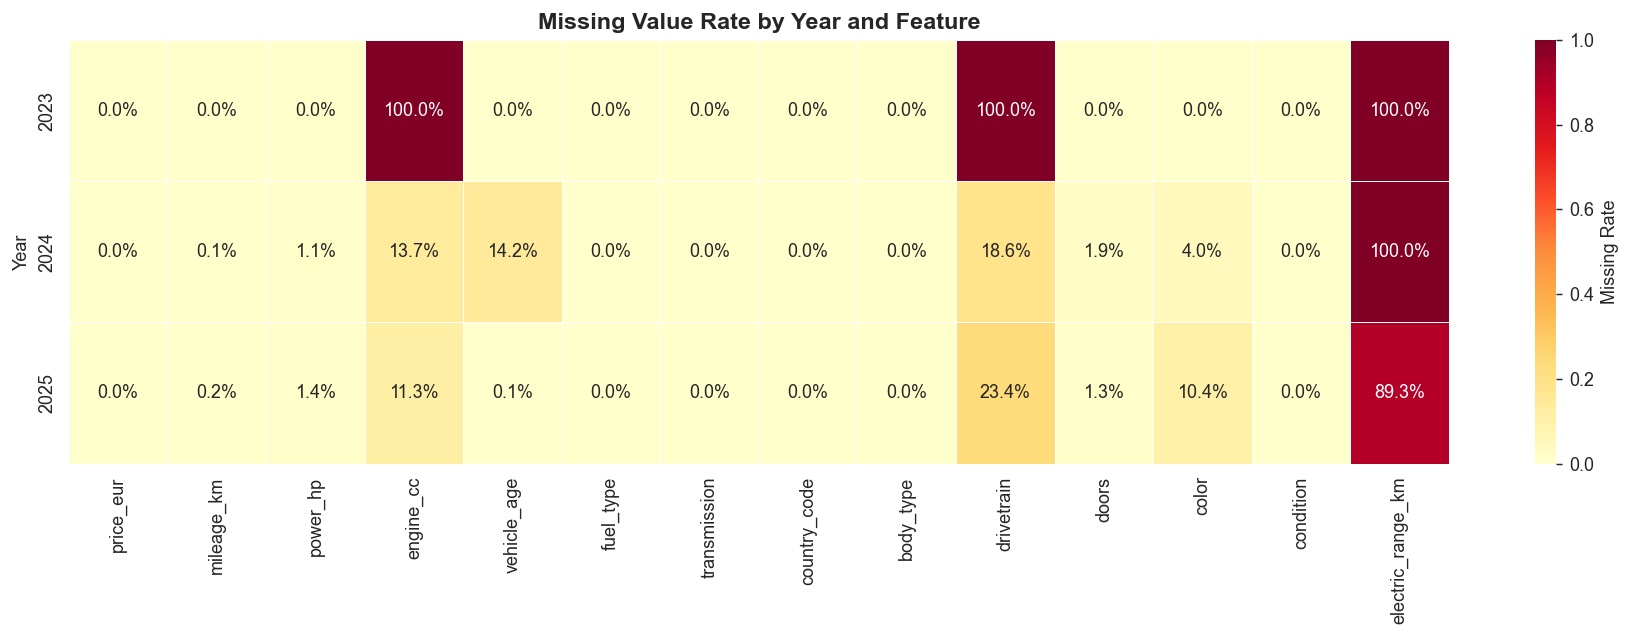

Figure saved.


In [4]:
# Missing value heatmap by year
key_cols = ['price_eur', 'mileage_km', 'power_hp', 'engine_cc', 'vehicle_age',
            'fuel_type', 'transmission', 'country_code', 'body_type', 'drivetrain',
            'doors', 'color', 'condition', 'electric_range_km']
key_cols = [c for c in key_cols if c in df.columns]

# Compute missing rates accounting for string 'nan' in object columns
miss_rates = []
for year in sorted(df['data_year'].unique()):
    yr_df = df[df['data_year'] == year]
    row = {}
    for col in key_cols:
        if col in yr_df.columns:
            n_miss = yr_df[col].isna().sum()
            if yr_df[col].dtype == object:
                n_miss += (yr_df[col].isin(['nan', 'None', ''])).sum()
            row[col] = n_miss / len(yr_df)
        else:
            row[col] = 1.0
    miss_rates.append(row)

miss_heatmap = pd.DataFrame(miss_rates, index=sorted(df['data_year'].unique()))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(miss_heatmap, annot=True, cmap='YlOrRd', fmt='.1%', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Missing Rate'})
ax.set_title('Missing Value Rate by Year and Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(FIGURES / '02_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 3. Price Distributions

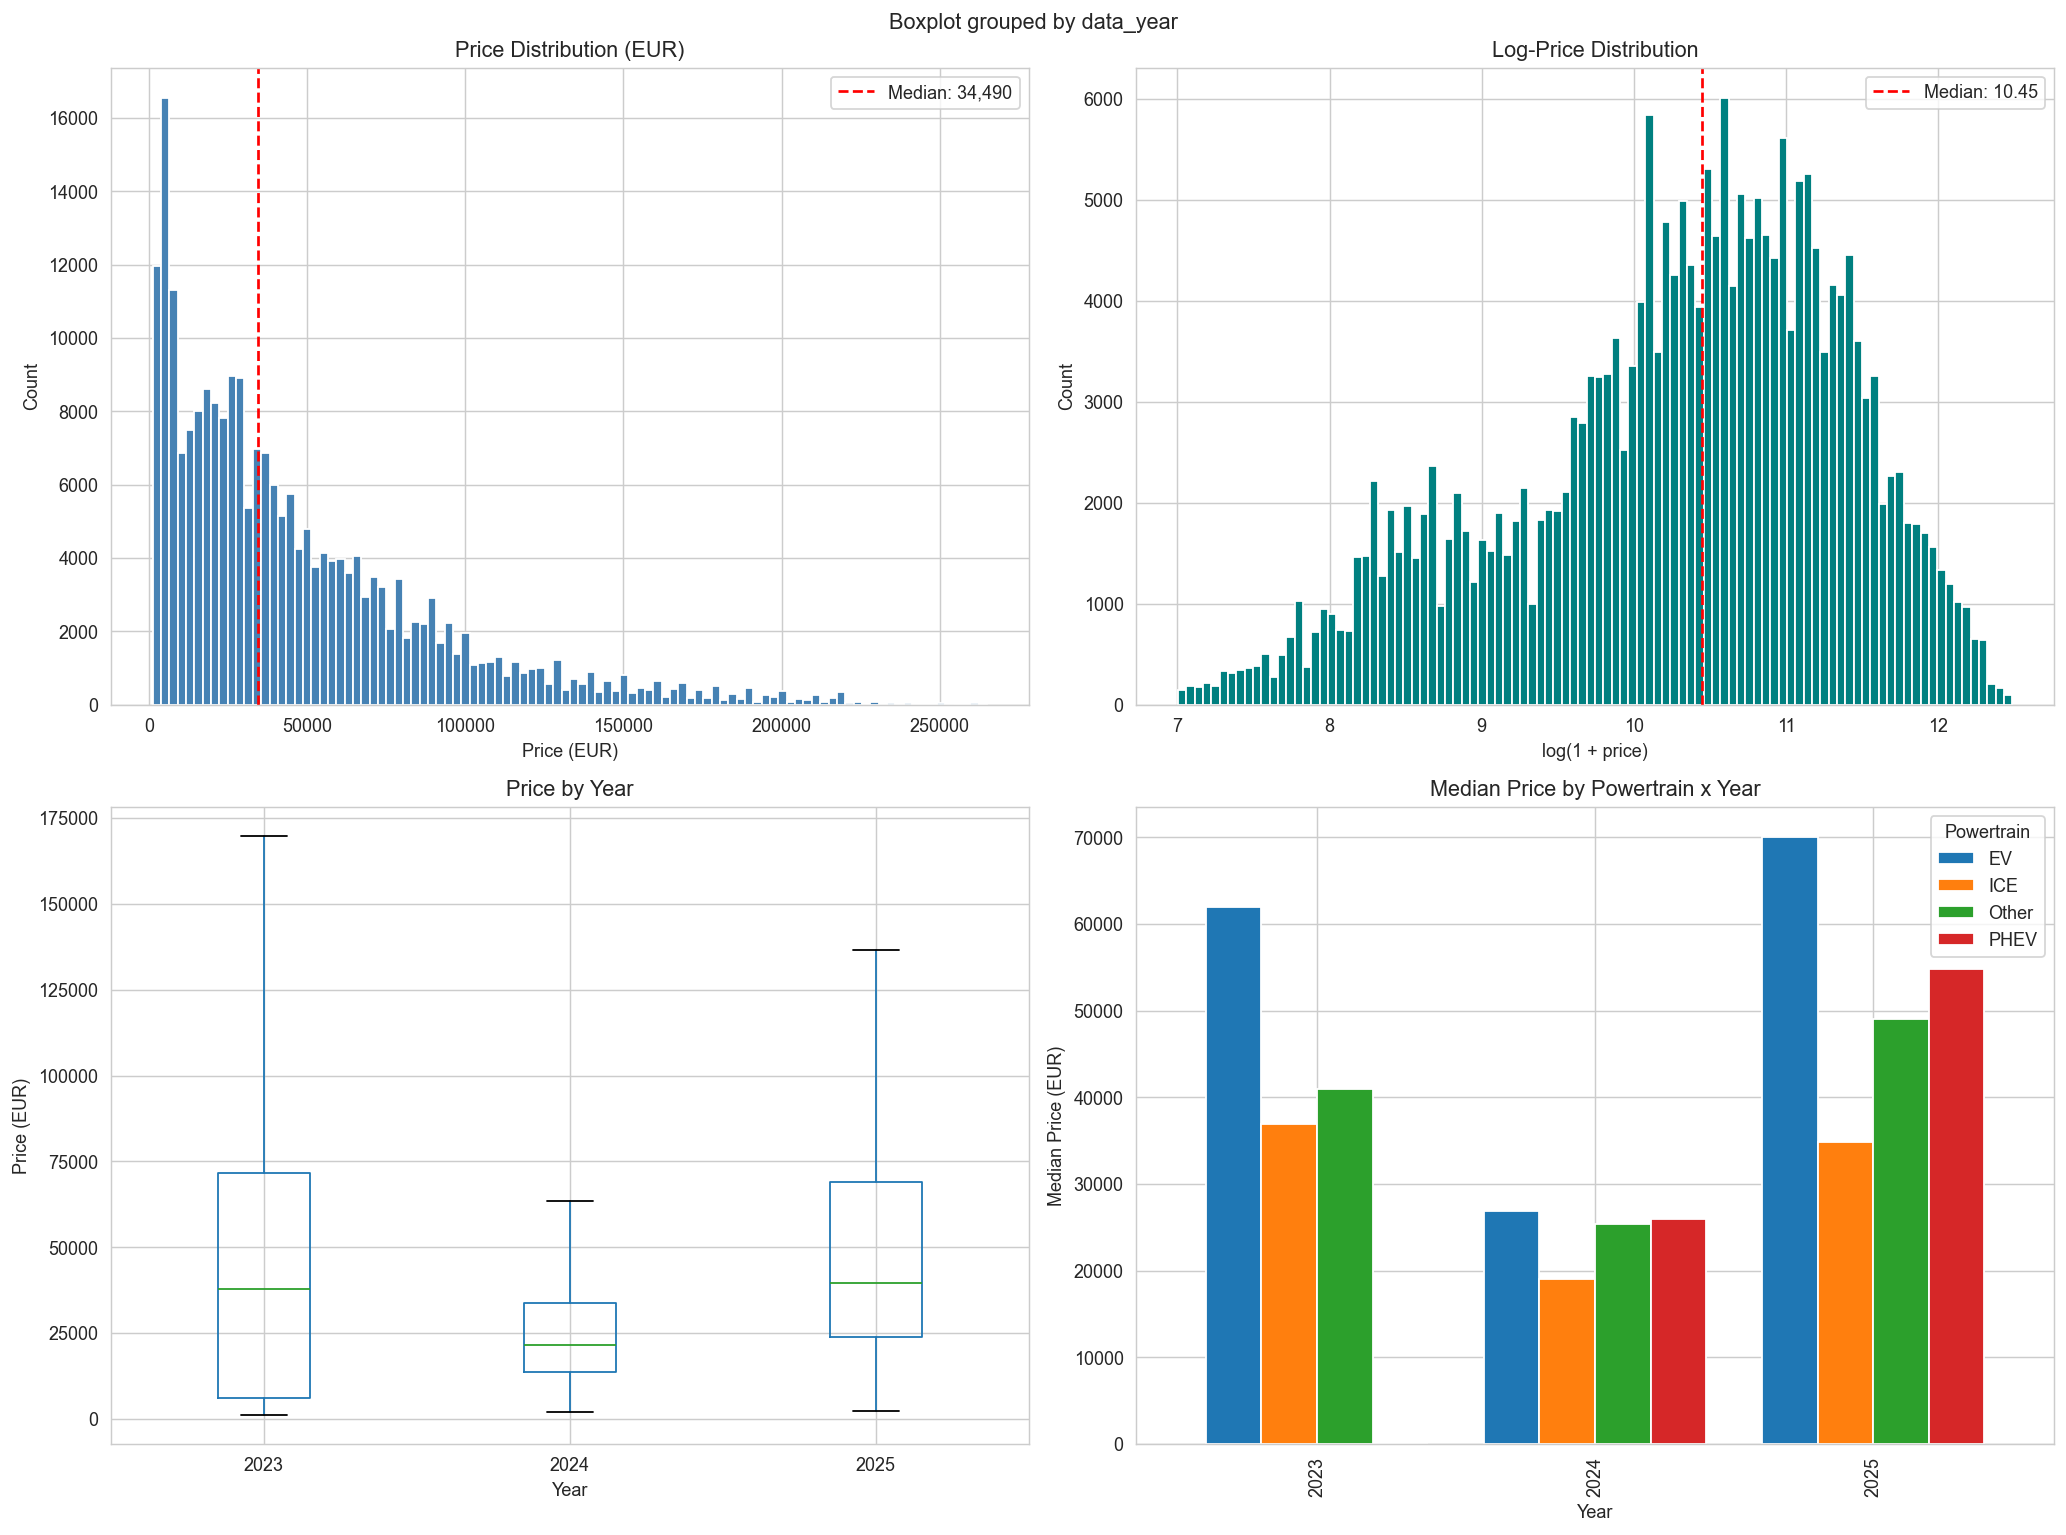

Figure saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price Distribution Analysis', fontsize=14, fontweight='bold')

# 3a. Raw price histogram
axes[0, 0].hist(df['price_eur'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution (EUR)')
axes[0, 0].set_xlabel('Price (EUR)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['price_eur'].median(), color='red', ls='--',
                    label=f'Median: {df["price_eur"].median():,.0f}')
axes[0, 0].legend()

# 3b. Log-price histogram
axes[0, 1].hist(df['log_price'].dropna(), bins=100, color='teal', edgecolor='white')
axes[0, 1].set_title('Log-Price Distribution')
axes[0, 1].set_xlabel('log(1 + price)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df['log_price'].median(), color='red', ls='--',
                    label=f'Median: {df["log_price"].median():.2f}')
axes[0, 1].legend()

# 3c. Boxplot by year
df.boxplot(column='price_eur', by='data_year', ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('Price by Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Price (EUR)')
plt.sca(axes[1, 0])
plt.title('Price by Year')

# 3d. Median price by powertrain x year
if 'powertrain' in df.columns:
    pivot = df.groupby(['data_year', 'powertrain'])['price_eur'].median().unstack()
    pivot.plot(kind='bar', ax=axes[1, 1], width=0.8)
    axes[1, 1].set_title('Median Price by Powertrain x Year')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Median Price (EUR)')
    axes[1, 1].legend(title='Powertrain')

plt.tight_layout()
plt.savefig(FIGURES / '02_price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [6]:
# Price statistics table
print('=' * 80)
print('PRICE STATISTICS BY YEAR')
print('=' * 80)
price_stats = df.groupby('data_year')['price_eur'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(0)
print(price_stats)

print(f'\n--- Median price by powertrain x year ---')
if 'powertrain' in df.columns:
    print(df.groupby(['data_year', 'powertrain'])['price_eur'].median().unstack().round(0))

PRICE STATISTICS BY YEAR
            count     mean   median      std     min       max
data_year                                                     
2023        86060  45242.0  37750.0  44555.0  1100.0  225500.0
2024        34964  34394.0  21595.0  42615.0  1900.0  265000.0
2025       107846  52251.0  39490.0  40625.0  2250.0  222000.0

--- Median price by powertrain x year ---
powertrain       EV      ICE    Other     PHEV
data_year                                     
2023        61990.0  36900.0  40990.0      NaN
2024        26897.0  18990.0  25400.0  25950.0
2025        69990.0  34900.0  49000.0  54825.0


## 4. Vehicle Characteristics

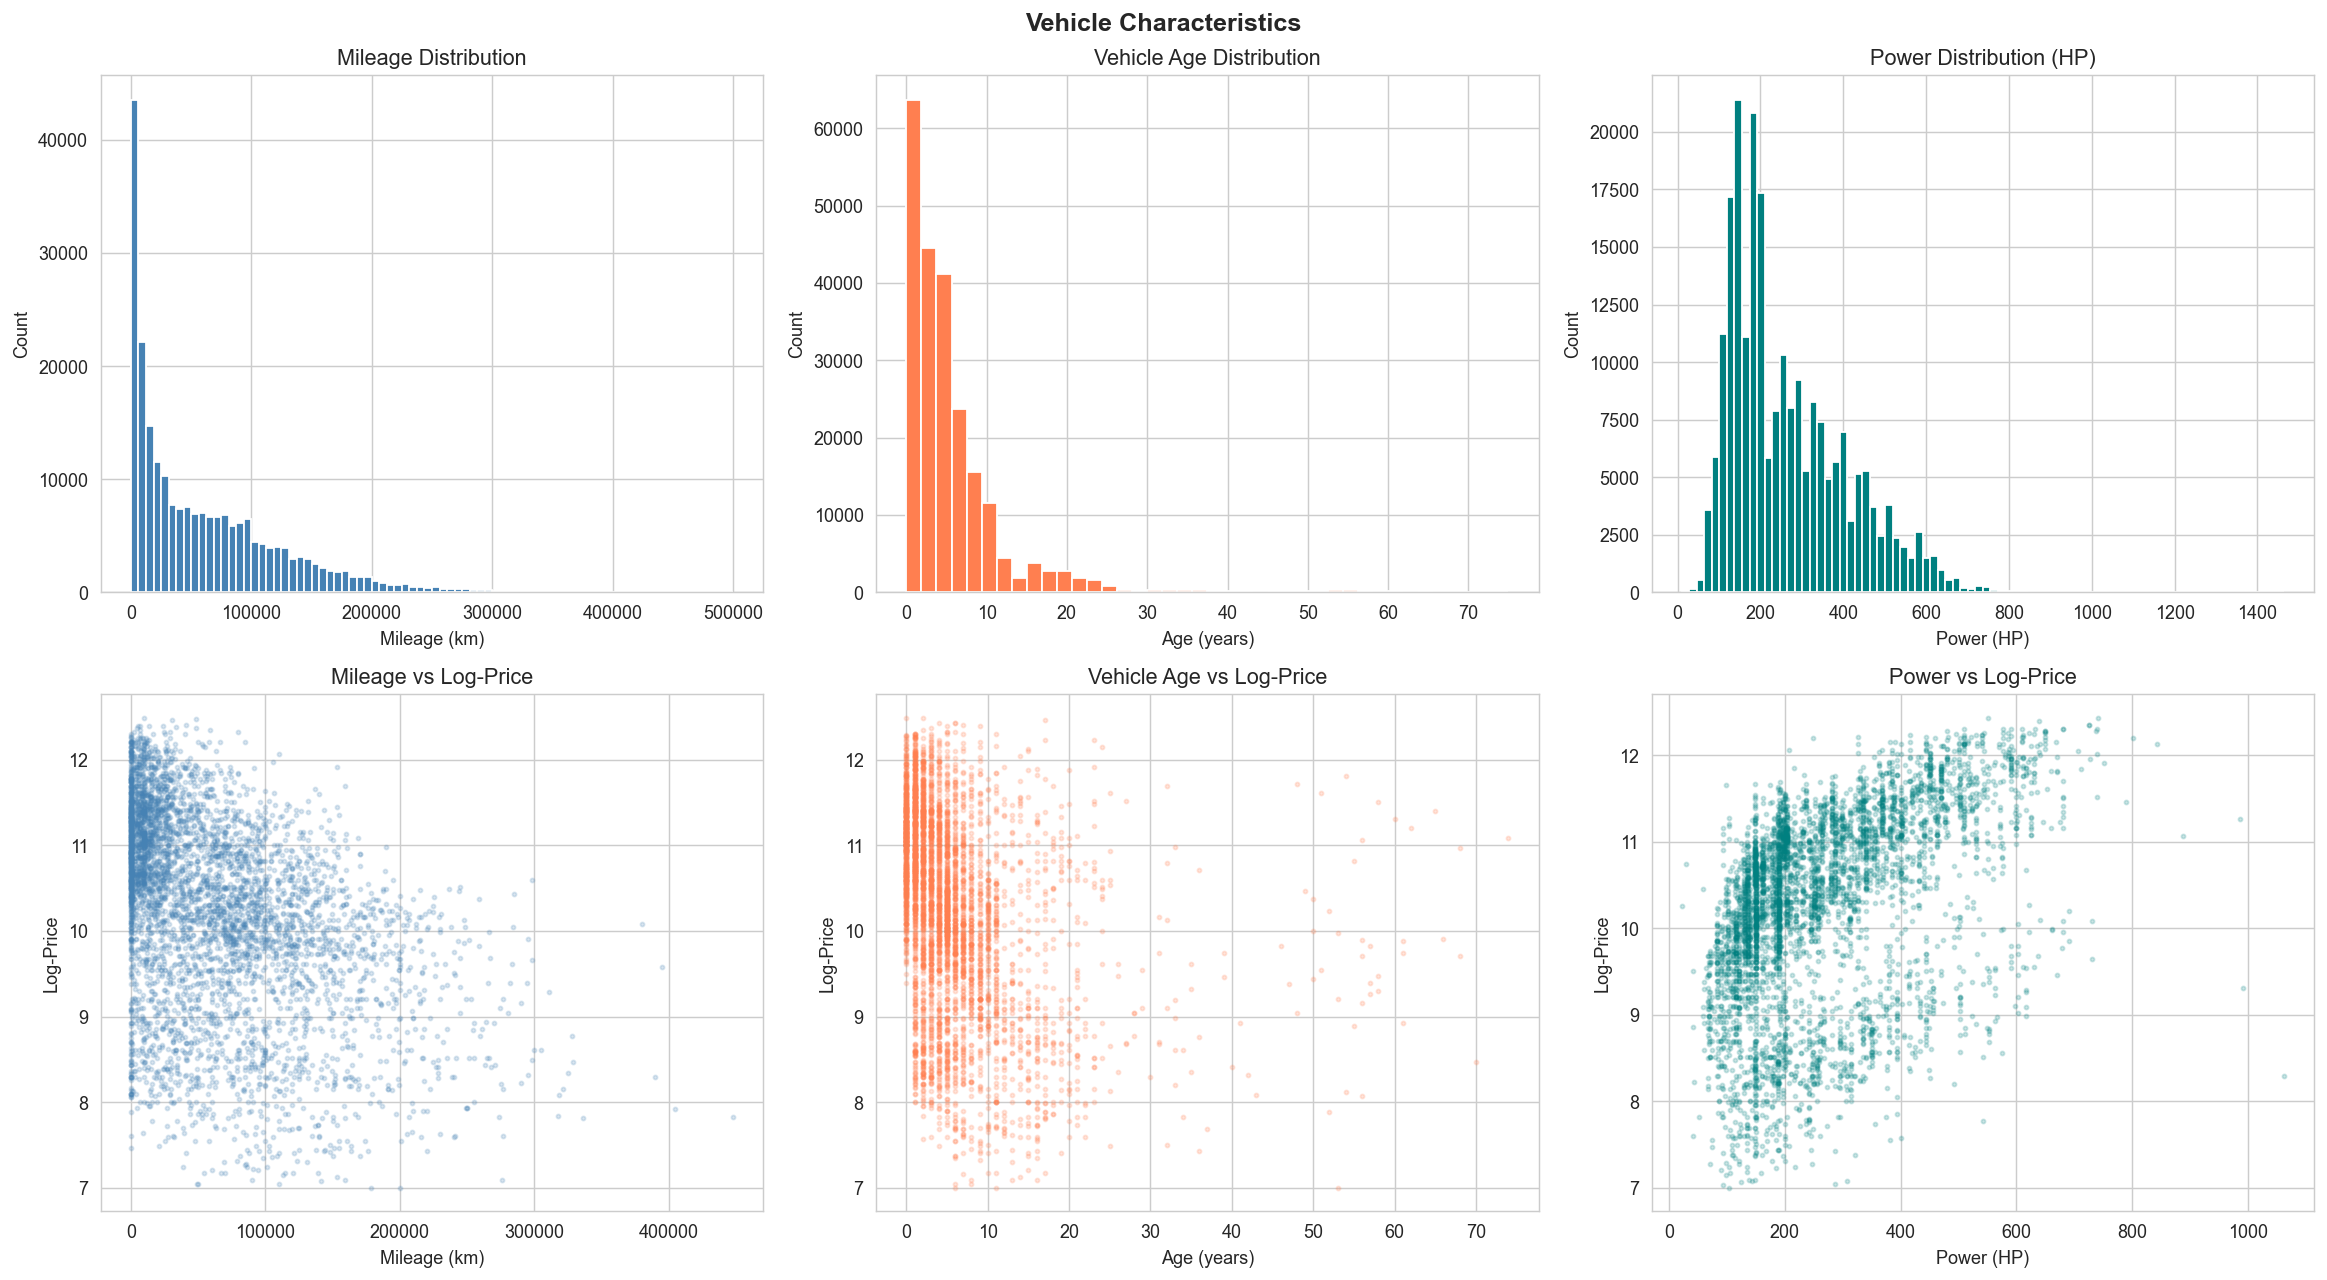

Figure saved.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Vehicle Characteristics', fontsize=14, fontweight='bold')

# 4a. Mileage distribution
axes[0, 0].hist(df['mileage_km'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Mileage Distribution')
axes[0, 0].set_xlabel('Mileage (km)')
axes[0, 0].set_ylabel('Count')

# 4b. Age distribution
axes[0, 1].hist(df['vehicle_age'].dropna(), bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title('Vehicle Age Distribution')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Count')

# 4c. Power distribution
axes[0, 2].hist(df['power_hp'].dropna(), bins=80, color='teal', edgecolor='white')
axes[0, 2].set_title('Power Distribution (HP)')
axes[0, 2].set_xlabel('Power (HP)')
axes[0, 2].set_ylabel('Count')

# 4d. Mileage vs price scatter
sample = df.dropna(subset=['mileage_km', 'log_price']).sample(
    min(5000, len(df)), random_state=42
)
axes[1, 0].scatter(sample['mileage_km'], sample['log_price'],
                   alpha=0.2, s=5, color='steelblue')
axes[1, 0].set_title('Mileage vs Log-Price')
axes[1, 0].set_xlabel('Mileage (km)')
axes[1, 0].set_ylabel('Log-Price')

# 4e. Age vs price scatter
sample2 = df.dropna(subset=['vehicle_age', 'log_price']).sample(
    min(5000, len(df)), random_state=42
)
axes[1, 1].scatter(sample2['vehicle_age'], sample2['log_price'],
                   alpha=0.2, s=5, color='coral')
axes[1, 1].set_title('Vehicle Age vs Log-Price')
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Log-Price')

# 4f. Power vs price scatter
sample3 = df.dropna(subset=['power_hp', 'log_price']).sample(
    min(5000, len(df)), random_state=42
)
axes[1, 2].scatter(sample3['power_hp'], sample3['log_price'],
                   alpha=0.2, s=5, color='teal')
axes[1, 2].set_title('Power vs Log-Price')
axes[1, 2].set_xlabel('Power (HP)')
axes[1, 2].set_ylabel('Log-Price')

plt.tight_layout()
plt.savefig(FIGURES / '02_vehicle_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Market Segmentation

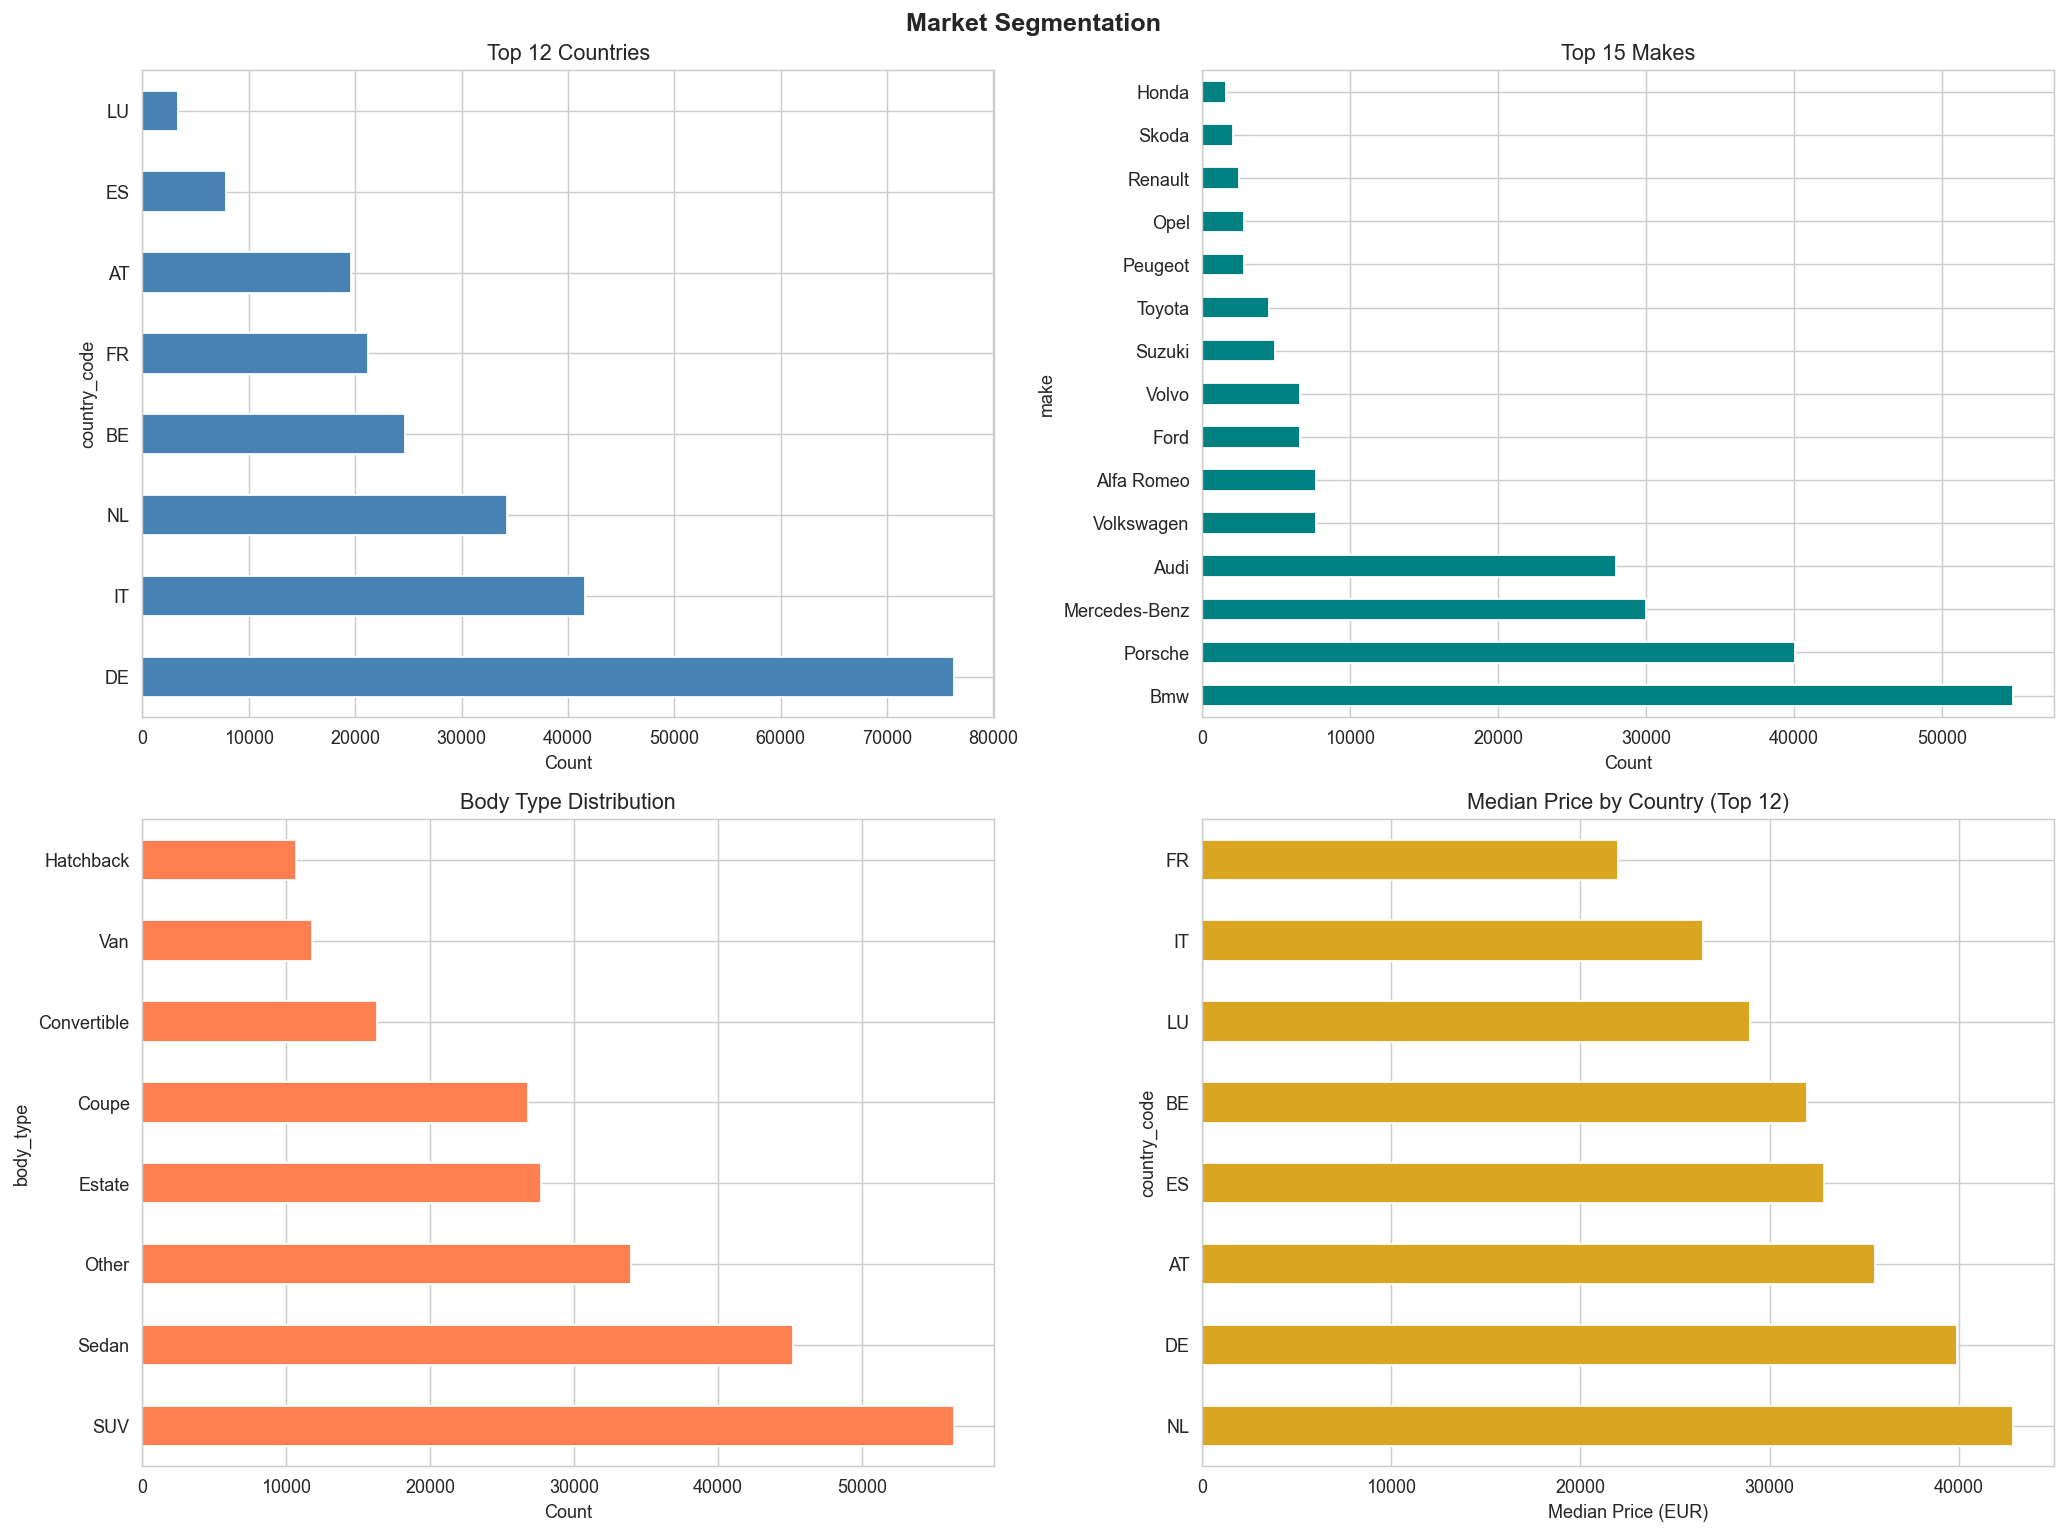

Figure saved.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Market Segmentation', fontsize=14, fontweight='bold')

# 5a. Country distribution
df['country_code'].value_counts().head(12).plot.barh(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top 12 Countries')
axes[0, 0].set_xlabel('Count')

# 5b. Top makes
df['make'].value_counts().head(15).plot.barh(ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Top 15 Makes')
axes[0, 1].set_xlabel('Count')

# 5c. Body type distribution
df['body_type'].value_counts().plot.barh(ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Body Type Distribution')
axes[1, 0].set_xlabel('Count')

# 5d. Median price by country
country_price = df.groupby('country_code')['price_eur'].median().sort_values(
    ascending=False
).head(12)
country_price.plot.barh(ax=axes[1, 1], color='goldenrod')
axes[1, 1].set_title('Median Price by Country (Top 12)')
axes[1, 1].set_xlabel('Median Price (EUR)')

plt.tight_layout()
plt.savefig(FIGURES / '02_market_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [9]:
# Detailed tables
print('=' * 80)
print('MARKET SEGMENTATION DETAILS')
print('=' * 80)

print(f'\n--- Country x Year ---')
print(pd.crosstab(df['data_year'], df['country_code']))

print(f'\n--- Top 10 makes by median price ---')
top_makes = df['make'].value_counts().head(20).index
make_stats = df[df['make'].isin(top_makes)].groupby('make')['price_eur'].agg(
    ['count', 'median', 'mean']
).sort_values('median', ascending=False)
print(make_stats.round(0))

MARKET SEGMENTATION DETAILS

--- Country x Year ---
country_code     AT     BE     DE    ES     FR     IT    LU     NL
data_year                                                         
2023          11623  12048  20033     0  14218  10261  2469  15408
2024           1200   3635  14275  1601   1155   9113   104   3881
2025           6802   9000  41937  6293   5879  22190   764  14981

--- Top 10 makes by median price ---
               count    median      mean
make                                    
Aston Martin    1061  109900.0  115534.0
Porsche        40043   59000.0   68014.0
Mercedes-Benz  30018   56900.0   63164.0
Audi           27951   47500.0   53434.0
Volkswagen      7721   45888.0   44586.0
Opel            2811   33995.0   30716.0
Peugeot         2811   31490.0   28644.0
Bmw            54844   30500.0   39610.0
Alfa Romeo      7683   27400.0   27319.0
Skoda           2072   24930.0   26917.0
Volvo           6585   23900.0   26367.0
Toyota          4524   22985.0   26853.0
J

## 6. EV vs ICE vs PHEV Comparison

In [10]:
ev = df[df['powertrain'] == 'EV']
ice = df[df['powertrain'] == 'ICE']
phev = df[df['powertrain'] == 'PHEV']

print('=' * 80)
print('EV vs ICE vs PHEV COMPARISON')
print('=' * 80)

for label, sub in [('EV', ev), ('ICE', ice), ('PHEV', phev)]:
    print(f'\n--- {label} ({len(sub):,} records) ---')
    print(f'  Price EUR:  median={sub["price_eur"].median():,.0f}, '
          f'mean={sub["price_eur"].mean():,.0f}')
    if 'mileage_km' in sub.columns:
        print(f'  Mileage:    median={sub["mileage_km"].median():,.0f}')
    if 'vehicle_age' in sub.columns:
        print(f'  Age:        median={sub["vehicle_age"].median():.1f}')
    if 'power_hp' in sub.columns:
        print(f'  Power HP:   median={sub["power_hp"].median():,.0f}')

# EV premium evolution
print(f'\n--- EV Premium (median EV / median ICE) ---')
for year in sorted(df['data_year'].unique()):
    ev_med = ev[ev['data_year'] == year]['price_eur'].median()
    ice_med = ice[ice['data_year'] == year]['price_eur'].median()
    if ice_med > 0 and not np.isnan(ev_med):
        premium = (ev_med / ice_med - 1) * 100
        print(f'  {year}: EV median={ev_med:,.0f}, ICE median={ice_med:,.0f}, '
              f'premium={premium:+.1f}%')

EV vs ICE vs PHEV COMPARISON

--- EV (12,066 records) ---
  Price EUR:  median=56,990, mean=59,010
  Mileage:    median=9,998
  Age:        median=1.0
  Power HP:   median=290

--- ICE (190,270 records) ---
  Price EUR:  median=31,870, mean=45,016
  Mileage:    median=47,365
  Age:        median=4.0
  Power HP:   median=218

--- PHEV (24,732 records) ---
  Price EUR:  median=41,999, mean=55,645
  Mileage:    median=28,386
  Age:        median=2.0
  Power HP:   median=242

--- EV Premium (median EV / median ICE) ---
  2023: EV median=61,990, ICE median=36,900, premium=+68.0%
  2024: EV median=26,897, ICE median=18,990, premium=+41.6%
  2025: EV median=69,990, ICE median=34,900, premium=+100.5%


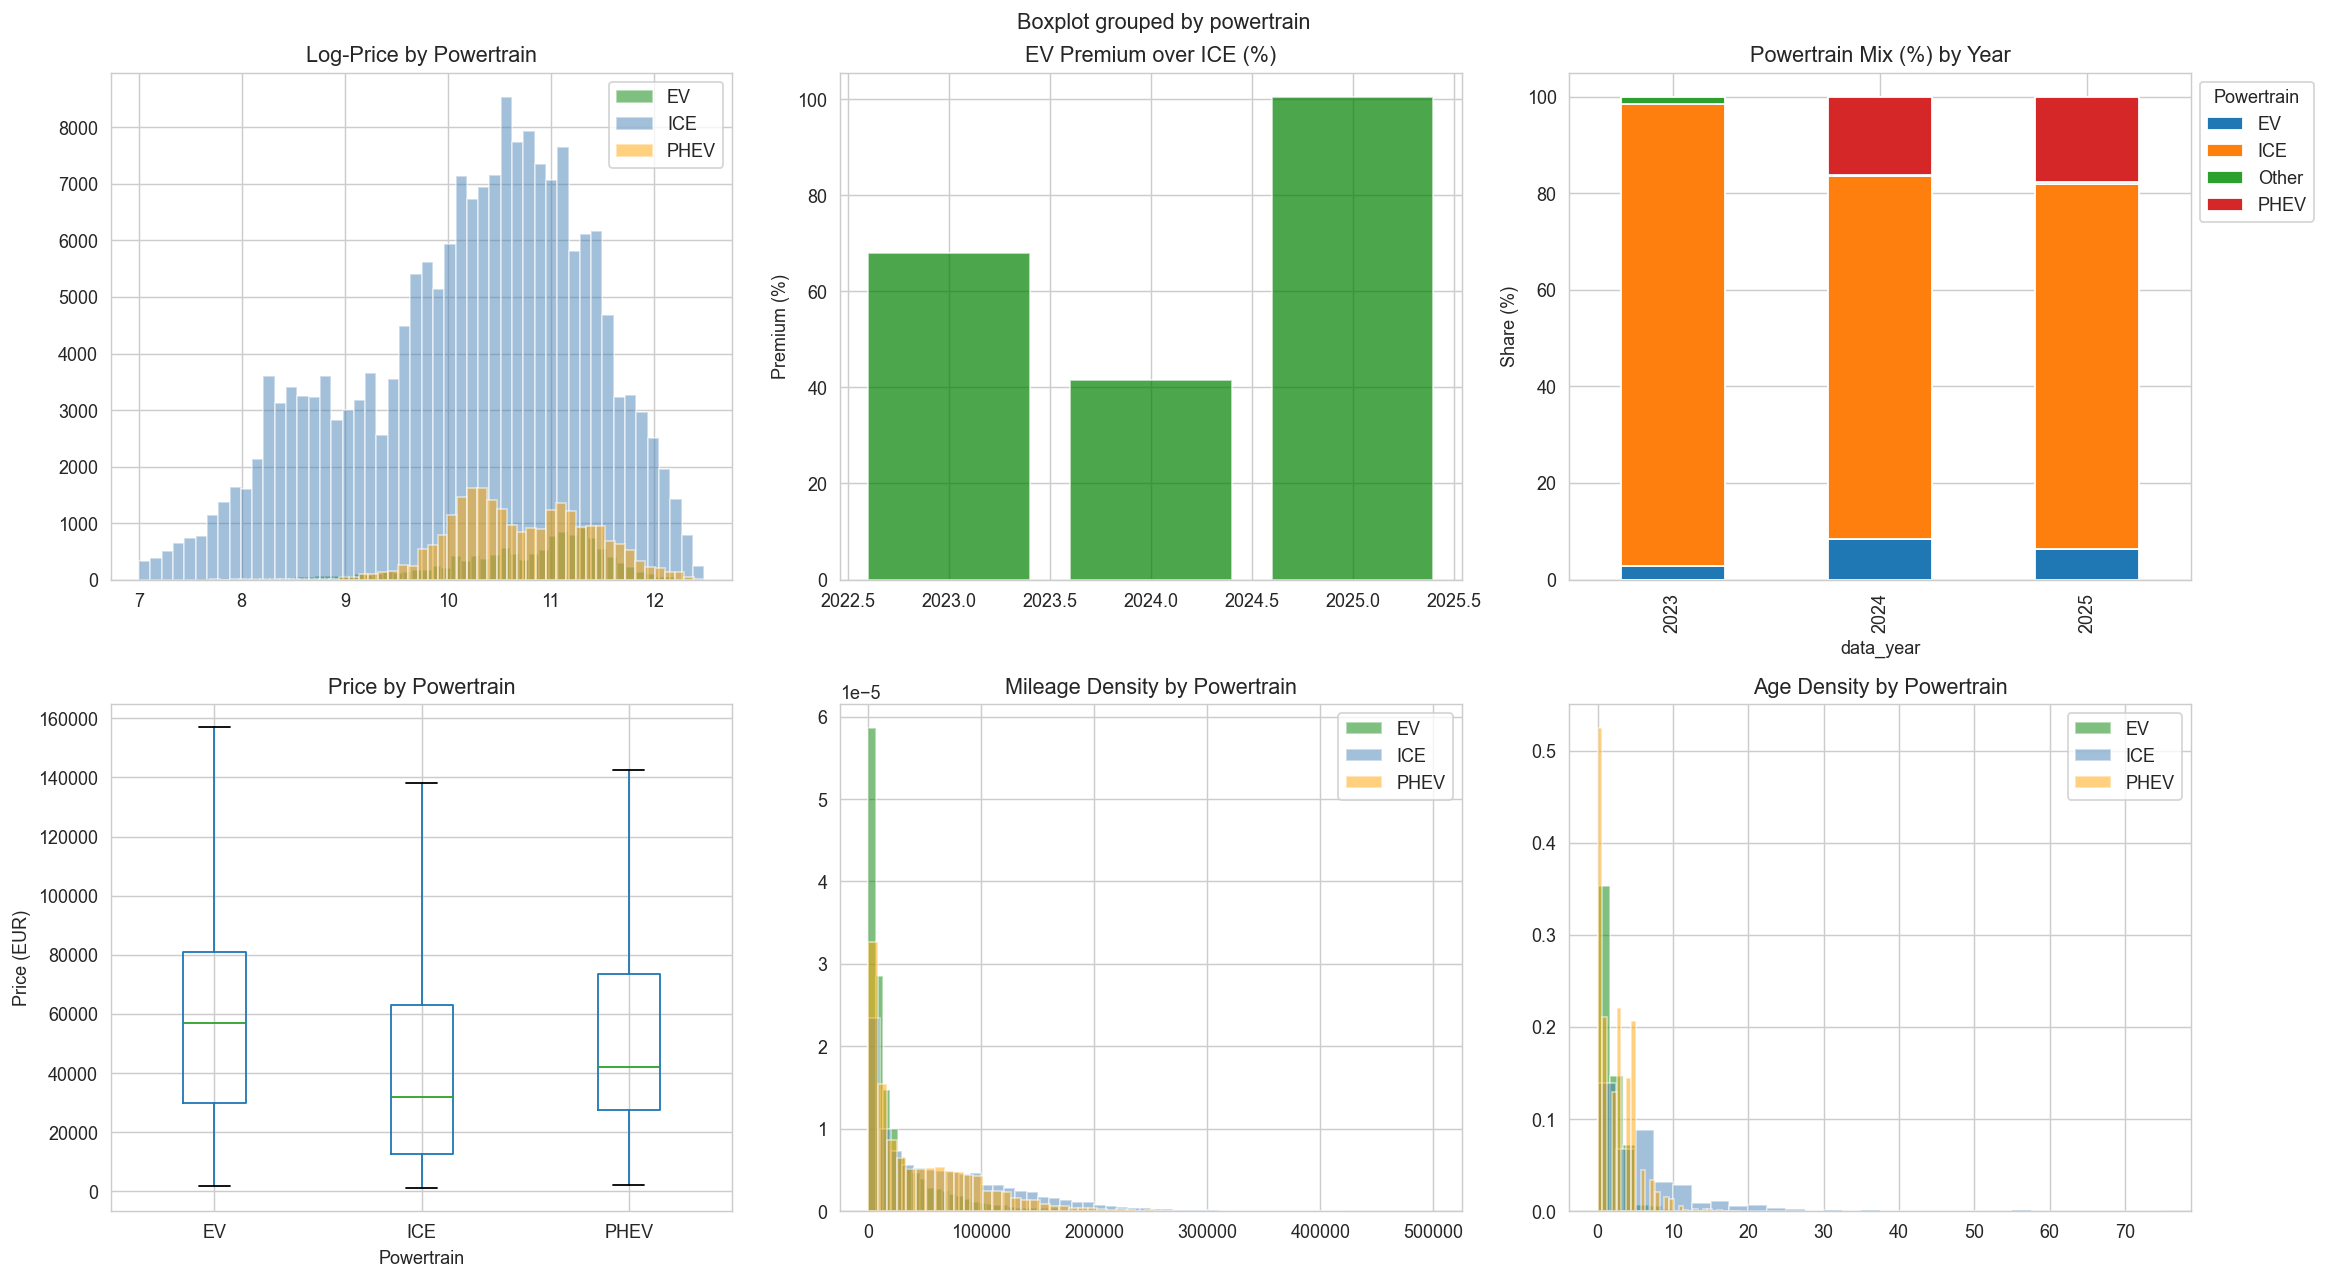

Figure saved.


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EV vs ICE vs PHEV Comparison', fontsize=14, fontweight='bold')

# 6a. Price distributions overlay
for label, sub, color in [('EV', ev, 'green'), ('ICE', ice, 'steelblue'),
                           ('PHEV', phev, 'orange')]:
    axes[0, 0].hist(sub['log_price'].dropna(), bins=50, alpha=0.5,
                    label=label, color=color)
axes[0, 0].set_title('Log-Price by Powertrain')
axes[0, 0].legend()

# 6b. EV premium evolution
years = sorted(df['data_year'].unique())
ev_premiums = []
for year in years:
    ev_med = ev[ev['data_year'] == year]['price_eur'].median()
    ice_med = ice[ice['data_year'] == year]['price_eur'].median()
    if ice_med > 0 and not np.isnan(ev_med):
        ev_premiums.append((ev_med / ice_med - 1) * 100)
    else:
        ev_premiums.append(0)
axes[0, 1].bar(years, ev_premiums, color='green', alpha=0.7)
axes[0, 1].set_title('EV Premium over ICE (%)')
axes[0, 1].set_ylabel('Premium (%)')
axes[0, 1].axhline(0, color='black', ls='--', lw=0.5)

# 6c. Powertrain mix by year (percentage)
pt_mix = pd.crosstab(df['data_year'], df['powertrain'], normalize='index') * 100
pt_mix.plot(kind='bar', stacked=True, ax=axes[0, 2])
axes[0, 2].set_title('Powertrain Mix (%) by Year')
axes[0, 2].set_ylabel('Share (%)')
axes[0, 2].legend(title='Powertrain', bbox_to_anchor=(1.0, 1.0))

# 6d. Price boxplot by powertrain
df[df['powertrain'].isin(['EV', 'ICE', 'PHEV'])].boxplot(
    column='price_eur', by='powertrain', ax=axes[1, 0], showfliers=False
)
axes[1, 0].set_title('Price by Powertrain')
axes[1, 0].set_xlabel('Powertrain')
axes[1, 0].set_ylabel('Price (EUR)')

# 6e. Mileage by powertrain
for label, sub, color in [('EV', ev, 'green'), ('ICE', ice, 'steelblue'),
                           ('PHEV', phev, 'orange')]:
    axes[1, 1].hist(sub['mileage_km'].dropna(), bins=50, alpha=0.5,
                    label=label, color=color, density=True)
axes[1, 1].set_title('Mileage Density by Powertrain')
axes[1, 1].legend()

# 6f. Age by powertrain
for label, sub, color in [('EV', ev, 'green'), ('ICE', ice, 'steelblue'),
                           ('PHEV', phev, 'orange')]:
    axes[1, 2].hist(sub['vehicle_age'].dropna(), bins=30, alpha=0.5,
                    label=label, color=color, density=True)
axes[1, 2].set_title('Age Density by Powertrain')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig(FIGURES / '02_ev_ice_phev_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 7. Correlation Analysis

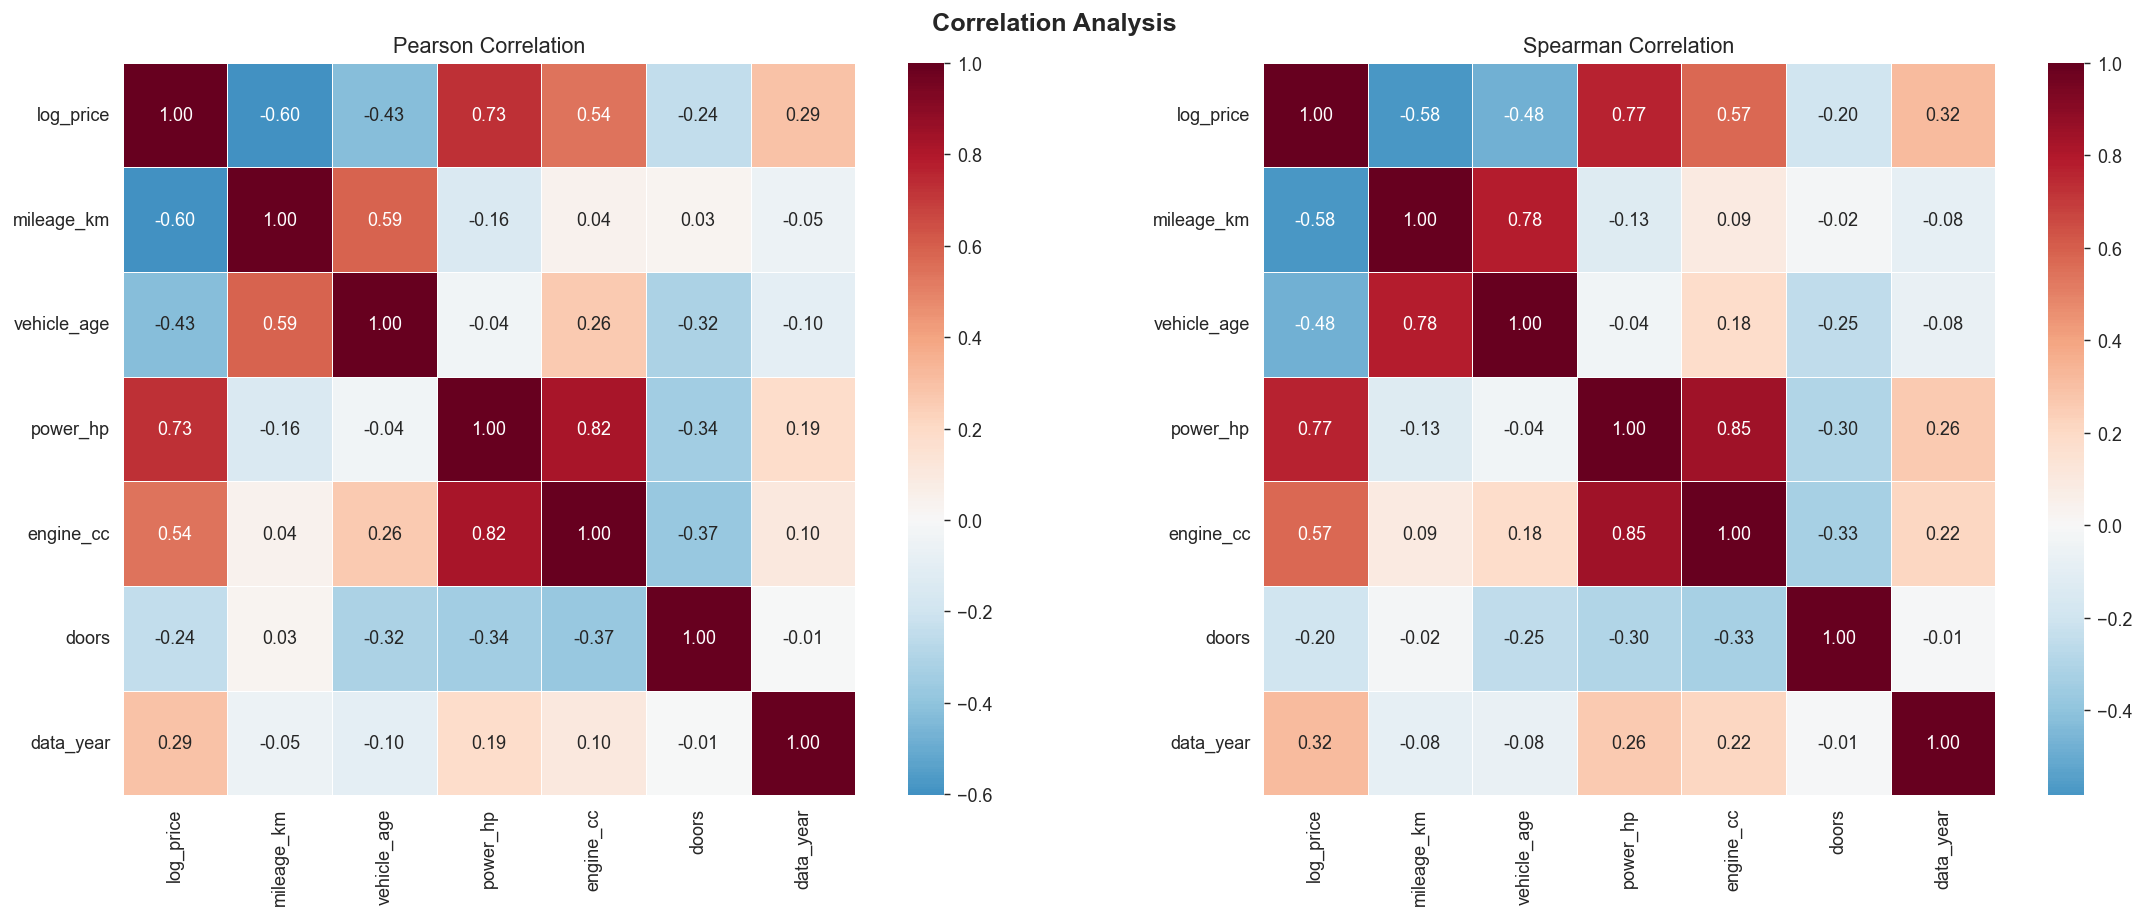

Figure saved.


In [12]:
corr_cols = ['log_price', 'mileage_km', 'vehicle_age', 'power_hp',
             'engine_cc', 'doors', 'data_year']
corr_cols = [c for c in corr_cols if c in df.columns]
corr_data = df[corr_cols].dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

# Pearson
pearson = corr_data.corr(method='pearson')
sns.heatmap(pearson, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[0],
            square=True, linewidths=0.5)
axes[0].set_title('Pearson Correlation')

# Spearman
spearman = corr_data.corr(method='spearman')
sns.heatmap(spearman, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1],
            square=True, linewidths=0.5)
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.savefig(FIGURES / '02_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [13]:
# Print top correlations with log_price
print('=' * 80)
print('TOP CORRELATIONS WITH LOG-PRICE')
print('=' * 80)
print(f'\nPearson:')
print(pearson['log_price'].drop('log_price').sort_values(key=abs, ascending=False))
print(f'\nSpearman:')
print(spearman['log_price'].drop('log_price').sort_values(key=abs, ascending=False))

TOP CORRELATIONS WITH LOG-PRICE

Pearson:
power_hp       0.727638
mileage_km    -0.601725
engine_cc      0.539282
vehicle_age   -0.426127
data_year      0.288133
doors         -0.239490
Name: log_price, dtype: float64

Spearman:
power_hp       0.767527
mileage_km    -0.583141
engine_cc      0.570279
vehicle_age   -0.482228
data_year      0.316170
doors         -0.196250
Name: log_price, dtype: float64


## 8. Statistical Tests

In [14]:
print('=' * 80)
print('STATISTICAL TESTS')
print('=' * 80)

test_results = {}

# -- 8a. Jarque-Bera normality test on log-price --
sample_lp = df['log_price'].dropna().sample(min(10000, len(df)), random_state=42)
jb_stat, jb_p = stats.jarque_bera(sample_lp)
print(f'\n--- 8a. Jarque-Bera Normality Test (log-price, n={len(sample_lp):,}) ---')
print(f'  JB statistic: {jb_stat:.2f}')
print(f'  p-value:      {jb_p:.2e}')
print(f'  Normal?       {"Yes" if jb_p > 0.05 else "No (reject H0 at 5%)"}')
test_results['jarque_bera'] = {
    'statistic': float(jb_stat),
    'p_value': float(jb_p),
    'interpretation': 'reject_normality' if jb_p < 0.05 else 'normal'
}

# -- 8b. Kruskal-Wallis: price across powertrain groups --
groups_pt = [
    grp['log_price'].dropna().values
    for _, grp in df[df['powertrain'].isin(['EV', 'ICE', 'PHEV'])].groupby('powertrain')
]
kw_stat, kw_p = stats.kruskal(*groups_pt)
print(f'\n--- 8b. Kruskal-Wallis: Log-Price by Powertrain (EV/ICE/PHEV) ---')
print(f'  H statistic: {kw_stat:.2f}')
print(f'  p-value:     {kw_p:.2e}')
print(f'  Differ?      {"Yes" if kw_p < 0.05 else "No"}')
test_results['kruskal_wallis_powertrain'] = {
    'statistic': float(kw_stat),
    'p_value': float(kw_p),
    'groups': ['EV', 'ICE', 'PHEV']
}

# -- 8c. Mann-Whitney U: EV vs ICE --
ev_prices = ev['log_price'].dropna().values
ice_prices = ice['log_price'].dropna().values
mw_stat, mw_p = stats.mannwhitneyu(ev_prices, ice_prices, alternative='two-sided')
print(f'\n--- 8c. Mann-Whitney U: EV vs ICE Log-Price ---')
print(f'  U statistic: {mw_stat:,.0f}')
print(f'  p-value:     {mw_p:.2e}')
print(f'  Differ?      {"Yes" if mw_p < 0.05 else "No"}')
test_results['mann_whitney_ev_ice'] = {
    'statistic': float(mw_stat),
    'p_value': float(mw_p)
}

# -- 8d. Kruskal-Wallis: price across countries (top 5) --
top5_countries = df['country_code'].value_counts().head(5).index.tolist()
groups_country = [
    grp['log_price'].dropna().values
    for _, grp in df[df['country_code'].isin(top5_countries)].groupby('country_code')
]
kw_c_stat, kw_c_p = stats.kruskal(*groups_country)
print(f'\n--- 8d. Kruskal-Wallis: Log-Price by Country (top 5) ---')
print(f'  Countries:   {top5_countries}')
print(f'  H statistic: {kw_c_stat:.2f}')
print(f'  p-value:     {kw_c_p:.2e}')
print(f'  Differ?      {"Yes" if kw_c_p < 0.05 else "No"}')
test_results['kruskal_wallis_country'] = {
    'statistic': float(kw_c_stat),
    'p_value': float(kw_c_p),
    'countries': top5_countries
}

STATISTICAL TESTS

--- 8a. Jarque-Bera Normality Test (log-price, n=10,000) ---
  JB statistic: 569.09
  p-value:      2.65e-124
  Normal?       No (reject H0 at 5%)

--- 8b. Kruskal-Wallis: Log-Price by Powertrain (EV/ICE/PHEV) ---
  H statistic: 6484.52
  p-value:     0.00e+00
  Differ?      Yes

--- 8c. Mann-Whitney U: EV vs ICE Log-Price ---
  U statistic: 1,489,754,604
  p-value:     0.00e+00
  Differ?      Yes

--- 8d. Kruskal-Wallis: Log-Price by Country (top 5) ---
  Countries:   ['DE', 'IT', 'NL', 'BE', 'FR']
  H statistic: 7820.88
  p-value:     0.00e+00
  Differ?      Yes


## 9. Save Statistical Tests to JSON

In [15]:
import json

# Add summary stats
test_results['dataset_summary'] = {
    'n_rows': int(len(df)),
    'n_cols': int(df.shape[1]),
    'years': sorted([int(y) for y in df['data_year'].unique()]),
    'n_countries': int(df['country_code'].nunique()),
    'n_makes': int(df['make'].nunique()),
    'price_median': float(df['price_eur'].median()),
    'price_mean': float(df['price_eur'].mean()),
    'ev_share_pct': float((df['powertrain'] == 'EV').mean() * 100),
    'phev_share_pct': float((df['powertrain'] == 'PHEV').mean() * 100),
}

# Add correlation highlights
test_results['pearson_with_log_price'] = {
    col: float(pearson.loc['log_price', col])
    for col in pearson.columns if col != 'log_price'
}
test_results['spearman_with_log_price'] = {
    col: float(spearman.loc['log_price', col])
    for col in spearman.columns if col != 'log_price'
}

out_path = DATA_PROC / 'statistical_tests.json'
with open(out_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f'Saved: {out_path}')
print(json.dumps(test_results, indent=2))

print('\n' + '=' * 80)
print('EDA COMPLETE')
print('=' * 80)

Saved: /Users/elbekmajidov/Developer/Master's in Data Science/University of Warsaw/master-thesis-9/notebooks/../data/processed/statistical_tests.json
{
  "jarque_bera": {
    "statistic": 569.0902126437875,
    "p_value": 2.652347798245613e-124,
    "interpretation": "reject_normality"
  },
  "kruskal_wallis_powertrain": {
    "statistic": 6484.517847184691,
    "p_value": 0.0,
    "groups": [
      "EV",
      "ICE",
      "PHEV"
    ]
  },
  "mann_whitney_ev_ice": {
    "statistic": 1489754604.0,
    "p_value": 0.0
  },
  "kruskal_wallis_country": {
    "statistic": 7820.882053453092,
    "p_value": 0.0,
    "countries": [
      "DE",
      "IT",
      "NL",
      "BE",
      "FR"
    ]
  },
  "dataset_summary": {
    "n_rows": 228870,
    "n_cols": 53,
    "years": [
      2023,
      2024,
      2025
    ],
    "n_countries": 8,
    "n_makes": 67,
    "price_median": 34490.0,
    "price_mean": 46887.471104994096,
    "ev_share_pct": 5.271988465067506,
    "phev_share_pct": 10.80613